In [1]:
# ============================================================
# Cell 1: Imports & Setup
# ============================================================
import pandas as pd
import numpy as np
import matplotlib.pyplot as plt
import seaborn as sns
from pathlib import Path
from sklearn.model_selection import train_test_split
from sklearn.linear_model import LogisticRegression
from sklearn.preprocessing import StandardScaler
from sklearn.metrics import (
    classification_report, roc_auc_score,
    confusion_matrix, ConfusionMatrixDisplay, roc_curve
)
from xgboost import XGBClassifier
import joblib
import warnings
warnings.filterwarnings("ignore")

sns.set_style("whitegrid")
plt.rcParams["figure.figsize"] = (8, 4)

# Paths — matches YOUR folder structure
BASE_DIR  = Path(r"C:\Users\dell\Desktop\ECommerce_Retention_LTV_Project")
DATA_DIR  = BASE_DIR / "Data" / "processed"
MODEL_DIR = BASE_DIR / "Data" / "models"
OUT_DIR   = BASE_DIR / "2_Notebooks" / "outputs"

MODEL_DIR.mkdir(parents=True, exist_ok=True)
OUT_DIR.mkdir(parents=True, exist_ok=True)

print("📁 Data dir :", DATA_DIR.resolve())
print("📁 Model dir:", MODEL_DIR.resolve())
print("📁 Plots dir:", OUT_DIR.resolve())

📁 Data dir : C:\Users\dell\Desktop\ECommerce_Retention_LTV_Project\Data\processed
📁 Model dir: C:\Users\dell\Desktop\ECommerce_Retention_LTV_Project\Data\models
📁 Plots dir: C:\Users\dell\Desktop\ECommerce_Retention_LTV_Project\2_Notebooks\outputs


In [2]:
# ============================================================
# Cell 2: Load the SQL-cleaned CSVs
# ============================================================
cleaned_data = pd.read_csv(DATA_DIR / "cleaned_data.csv", parse_dates=["invoice_date"])
rfm_summary  = pd.read_csv(DATA_DIR / "rfm_summary.csv")
cohort       = pd.read_csv(DATA_DIR / "cohort_retention_matrix.csv")
churn_data   = pd.read_csv(DATA_DIR / "churn_modeling_data.csv")

print("cleaned_data :", cleaned_data.shape)
print("rfm_summary  :", rfm_summary.shape)
print("cohort       :", cohort.shape)
print("churn_data   :", churn_data.shape)
print()
print("Churn class balance:")
print(churn_data["is_churned"].value_counts())
print((churn_data["is_churned"].value_counts(normalize=True) * 100).round(1).astype(str) + "%")

cleaned_data : (397880, 9)
rfm_summary  : (4338, 4)
cohort       : (90, 5)
churn_data   : (3370, 7)

Churn class balance:
is_churned
0    1921
1    1449
Name: count, dtype: int64
is_churned
0    57.0%
1    43.0%
Name: proportion, dtype: str


In [3]:
# ============================================================
# Cell 3: Light cleaning + sanity checks
# ============================================================

# Type enforcement
rfm_summary["customer_id"] = rfm_summary["customer_id"].astype(int)
rfm_summary["recency"]     = rfm_summary["recency"].astype(int)
rfm_summary["frequency"]   = rfm_summary["frequency"].astype(int)
rfm_summary["monetary"]    = rfm_summary["monetary"].astype(float)

# Drop any residual NaN
before = len(rfm_summary)
rfm_summary = rfm_summary.dropna().reset_index(drop=True)
print(f"🧹 Dropped {before - len(rfm_summary)} NaN rows")

# Cap monetary at 99th percentile (handles outliers)
cap = rfm_summary["monetary"].quantile(0.99)
rfm_summary["monetary_capped"] = rfm_summary["monetary"].clip(upper=cap)
print(f"🧹 Capped monetary at 99th percentile = £{cap:,.2f}")

# Sanity checks on churn data
assert churn_data["recency"].min() >= 0, "❌ Negative recency!"
assert churn_data["frequency"].min() >= 1, "❌ Zero frequency!"
assert churn_data["monetary"].min() >= 0, "❌ Negative monetary!"
print("✅ churn_data passed all validations")

# Check NaNs across all
for name, df in [("cleaned_data", cleaned_data),
                 ("rfm_summary",  rfm_summary),
                 ("cohort",       cohort),
                 ("churn_data",   churn_data)]:
    n = df.isna().sum().sum()
    print(f"   {name:15s} → {n} NaN cells")

print("\n--- RFM Summary After Cleaning ---")
print(rfm_summary[["recency", "frequency", "monetary"]].describe().round(2))

🧹 Dropped 0 NaN rows
🧹 Capped monetary at 99th percentile = £19,881.00
✅ churn_data passed all validations
   cleaned_data    → 0 NaN cells
   rfm_summary     → 0 NaN cells
   cohort          → 0 NaN cells
   churn_data      → 0 NaN cells

--- RFM Summary After Cleaning ---
       recency  frequency   monetary
count  4338.00    4338.00    4338.00
mean     93.06       4.27    2054.27
std     100.01       7.70    8989.23
min       1.00       1.00       3.75
25%      18.00       1.00     307.41
50%      51.00       2.00     674.48
75%     142.75       5.00    1661.74
max     374.00     209.00  280206.02


invoice
Repeat buyer      2845
One-time buyer    1493
Name: count, dtype: int64

invoice
Repeat buyer      65.6%
One-time buyer    34.4%
Name: count, dtype: str


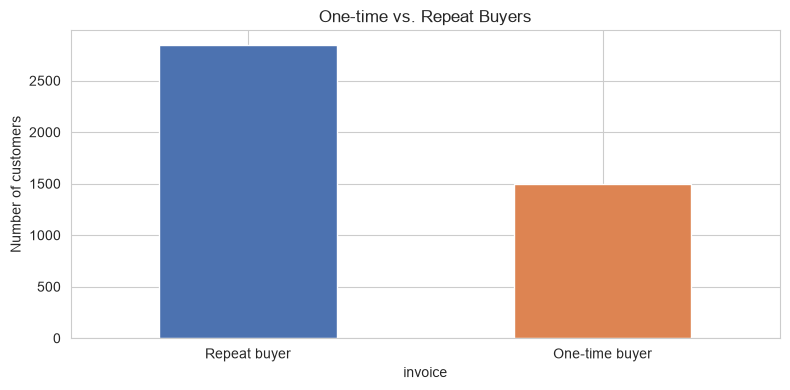


Spend by buyer type:
                   mean   median  count
buyer_type                             
One-time buyer   412.80   257.68   1493
Repeat buyer    2915.68  1160.07   2845


In [4]:
# ============================================================
# Cell 4: EDA — One-time vs Repeat Buyers
# ============================================================
orders_per_customer = cleaned_data.groupby("customer_id")["invoice"].nunique()

buyer_type = pd.cut(
    orders_per_customer,
    bins=[0, 1, orders_per_customer.max()],
    labels=["One-time buyer", "Repeat buyer"]
)
buyer_counts = buyer_type.value_counts()
buyer_pct = (buyer_counts / buyer_counts.sum() * 100).round(1)

print(buyer_counts)
print()
print(buyer_pct.astype(str) + "%")

# Plot
fig, ax = plt.subplots()
buyer_counts.plot(kind="bar", ax=ax, color=["#4C72B0", "#DD8452"])
ax.set_title("One-time vs. Repeat Buyers")
ax.set_ylabel("Number of customers")
plt.xticks(rotation=0)
plt.tight_layout()
plt.savefig(OUT_DIR / "buyer_type.png", dpi=100, bbox_inches="tight")
plt.show()

# Do repeat buyers spend more?
spend_by_type = cleaned_data.groupby("customer_id")["line_total"].sum().to_frame("total_spend")
spend_by_type["buyer_type"] = buyer_type
print("\nSpend by buyer type:")
print(spend_by_type.groupby("buyer_type")["total_spend"].agg(["mean", "median", "count"]).round(2))

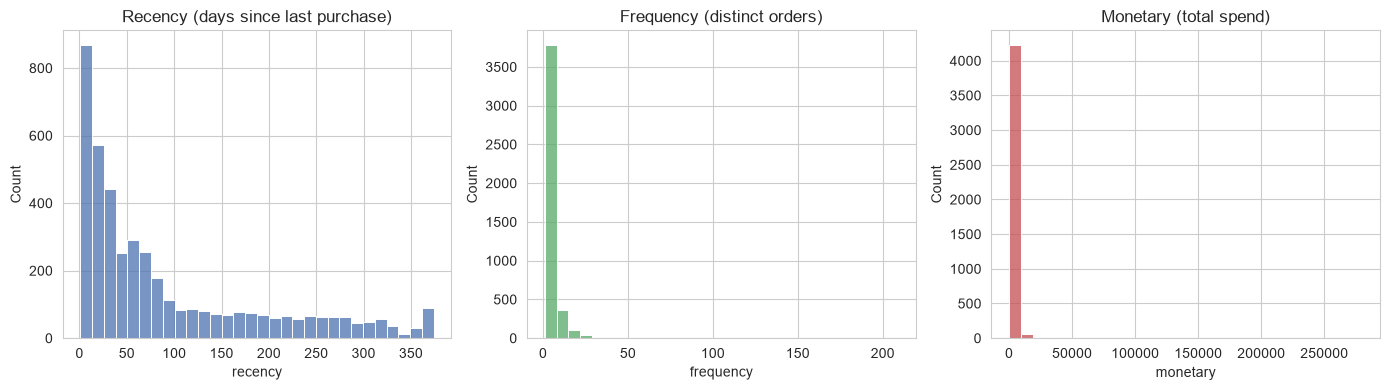

       recency  frequency   monetary
count  4338.00    4338.00    4338.00
mean     93.06       4.27    2054.27
std     100.01       7.70    8989.23
min       1.00       1.00       3.75
25%      18.00       1.00     307.41
50%      51.00       2.00     674.48
75%     142.75       5.00    1661.74
max     374.00     209.00  280206.02


In [5]:
# ============================================================
# Cell 5: EDA — RFM Distributions
# ============================================================
fig, axes = plt.subplots(1, 3, figsize=(14, 4))

sns.histplot(rfm_summary["recency"], bins=30, ax=axes[0], color="#4C72B0")
axes[0].set_title("Recency (days since last purchase)")

sns.histplot(rfm_summary["frequency"], bins=30, ax=axes[1], color="#55A868")
axes[1].set_title("Frequency (distinct orders)")

sns.histplot(rfm_summary["monetary"], bins=30, ax=axes[2], color="#C44E52")
axes[2].set_title("Monetary (total spend)")

plt.tight_layout()
plt.savefig(OUT_DIR / "rfm_distributions.png", dpi=100, bbox_inches="tight")
plt.show()

print(rfm_summary[["recency", "frequency", "monetary"]].describe().round(2))

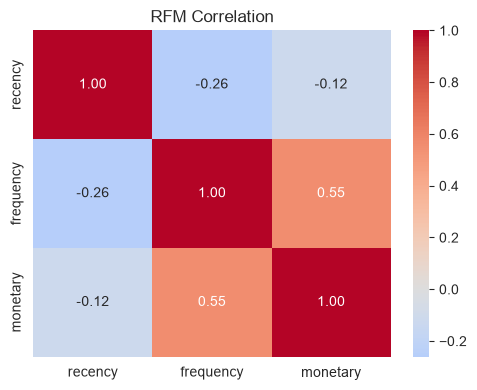

           recency  frequency  monetary
recency      1.000     -0.261    -0.122
frequency   -0.261      1.000     0.554
monetary    -0.122      0.554     1.000


In [6]:
# ============================================================
# Cell 6: EDA — RFM Correlation
# ============================================================
corr = rfm_summary[["recency", "frequency", "monetary"]].corr()

fig, ax = plt.subplots(figsize=(5, 4))
sns.heatmap(corr, annot=True, cmap="coolwarm", center=0, ax=ax, fmt=".2f")
ax.set_title("RFM Correlation")
plt.tight_layout()
plt.savefig(OUT_DIR / "rfm_correlation.png", dpi=100, bbox_inches="tight")
plt.show()

print(corr.round(3))

In [7]:
# ============================================================
# Cell 8: Feature selection & Train/Test split
# ============================================================
feature_cols = ["recency", "frequency", "monetary", "avg_order_value", "unique_products"]

X = churn_data[feature_cols]
y = churn_data["is_churned"]

X_train, X_test, y_train, y_test = train_test_split(
    X, y, test_size=0.25, random_state=42, stratify=y
)

print(f"Train: {X_train.shape[0]} customers | Test: {X_test.shape[0]} customers")
print(f"Train churn rate: {y_train.mean():.1%}")
print(f"Test churn rate : {y_test.mean():.1%}")

Train: 2527 customers | Test: 843 customers
Train churn rate: 43.0%
Test churn rate : 42.9%


LOGISTIC REGRESSION RESULTS
              precision    recall  f1-score   support

           0       0.72      0.71      0.72       481
           1       0.62      0.63      0.63       362

    accuracy                           0.68       843
   macro avg       0.67      0.67      0.67       843
weighted avg       0.68      0.68      0.68       843

ROC-AUC: 0.732


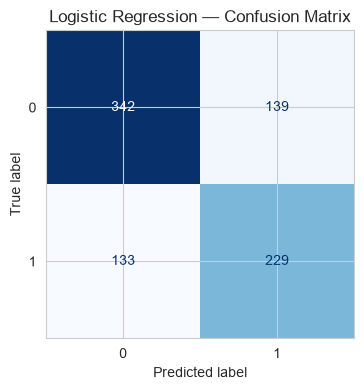

In [8]:
# ============================================================
# Cell 9: Logistic Regression
# ============================================================
scaler = StandardScaler()
X_train_scaled = scaler.fit_transform(X_train)
X_test_scaled  = scaler.transform(X_test)

log_reg = LogisticRegression(random_state=42, max_iter=1000)
log_reg.fit(X_train_scaled, y_train)

y_pred_lr = log_reg.predict(X_test_scaled)
y_proba_lr = log_reg.predict_proba(X_test_scaled)[:, 1]

print("=" * 50)
print("LOGISTIC REGRESSION RESULTS")
print("=" * 50)
print(classification_report(y_test, y_pred_lr))
print(f"ROC-AUC: {roc_auc_score(y_test, y_proba_lr):.3f}")

# Confusion matrix plot
fig, ax = plt.subplots(figsize=(4, 4))
ConfusionMatrixDisplay(confusion_matrix(y_test, y_pred_lr)).plot(
    ax=ax, cmap="Blues", colorbar=False
)
ax.set_title("Logistic Regression — Confusion Matrix")
plt.tight_layout()
plt.savefig(OUT_DIR / "confusion_matrix_lr.png", dpi=100, bbox_inches="tight")
plt.show()

XGBOOST RESULTS
              precision    recall  f1-score   support

           0       0.70      0.72      0.71       481
           1       0.61      0.58      0.59       362

    accuracy                           0.66       843
   macro avg       0.65      0.65      0.65       843
weighted avg       0.66      0.66      0.66       843

ROC-AUC: 0.719


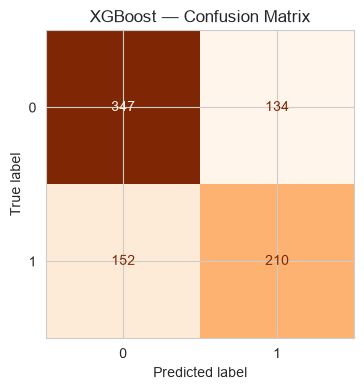

In [9]:
# ============================================================
# Cell 10: XGBoost (comparison model)
# ============================================================
xgb = XGBClassifier(
    random_state=42,
    eval_metric="logloss",
    n_estimators=100,
    max_depth=3,
    learning_rate=0.1
)
xgb.fit(X_train, y_train)

y_pred_xgb  = xgb.predict(X_test)
y_proba_xgb = xgb.predict_proba(X_test)[:, 1]

print("=" * 50)
print("XGBOOST RESULTS")
print("=" * 50)
print(classification_report(y_test, y_pred_xgb))
print(f"ROC-AUC: {roc_auc_score(y_test, y_proba_xgb):.3f}")

fig, ax = plt.subplots(figsize=(4, 4))
ConfusionMatrixDisplay(confusion_matrix(y_test, y_pred_xgb)).plot(
    ax=ax, cmap="Oranges", colorbar=False
)
ax.set_title("XGBoost — Confusion Matrix")
plt.tight_layout()
plt.savefig(OUT_DIR / "confusion_matrix_xgb.png", dpi=100, bbox_inches="tight")
plt.show()

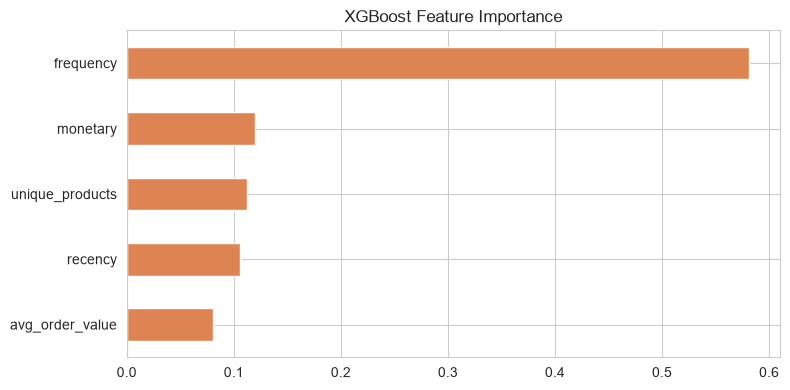


Feature Importance:
frequency          0.5811
monetary           0.1199
unique_products    0.1125
recency            0.1062
avg_order_value    0.0802
dtype: float32


In [10]:
# ============================================================
# Cell 11: Feature Importance (XGBoost)
# ============================================================
feat_importance = pd.Series(
    xgb.feature_importances_, index=feature_cols
).sort_values(ascending=False)

fig, ax = plt.subplots(figsize=(8, 4))
feat_importance.plot(kind="barh", ax=ax, color="#DD8452")
ax.set_title("XGBoost Feature Importance")
ax.invert_yaxis()
plt.tight_layout()
plt.savefig(OUT_DIR / "feature_importance.png", dpi=100, bbox_inches="tight")
plt.show()

print("\nFeature Importance:")
print(feat_importance.round(4))

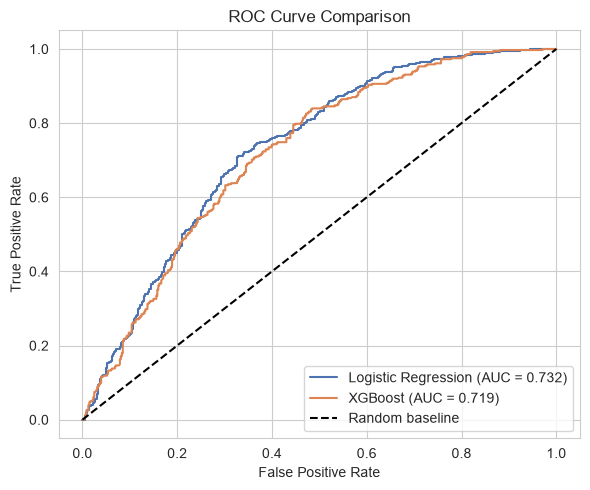

In [11]:
# ============================================================
# Cell 12: ROC Curve comparison
# ============================================================
fpr_lr, tpr_lr, _ = roc_curve(y_test, y_proba_lr)
fpr_xgb, tpr_xgb, _ = roc_curve(y_test, y_proba_xgb)

auc_lr  = roc_auc_score(y_test, y_proba_lr)
auc_xgb = roc_auc_score(y_test, y_proba_xgb)

fig, ax = plt.subplots(figsize=(6, 5))
ax.plot(fpr_lr,  tpr_lr,  label=f"Logistic Regression (AUC = {auc_lr:.3f})",  color="#4C72B0")
ax.plot(fpr_xgb, tpr_xgb, label=f"XGBoost (AUC = {auc_xgb:.3f})",             color="#DD8452")
ax.plot([0, 1], [0, 1], "k--", label="Random baseline")
ax.set_xlabel("False Positive Rate")
ax.set_ylabel("True Positive Rate")
ax.set_title("ROC Curve Comparison")
ax.legend(loc="lower right")
plt.tight_layout()
plt.savefig(OUT_DIR / "roc_curves.png", dpi=100, bbox_inches="tight")
plt.show()

In [12]:
# ============================================================
# Cell 13: Save Logistic Regression model + scaler
# ============================================================
model_bundle = {
    "model":        log_reg,
    "scaler":       scaler,
    "feature_cols": feature_cols,
}

joblib.dump(model_bundle, MODEL_DIR / "churn_model.pkl")

# Verify reload works
reloaded = joblib.load(MODEL_DIR / "churn_model.pkl")
check_preds = reloaded["model"].predict(
    reloaded["scaler"].transform(X_test[reloaded["feature_cols"]])
)

assert (check_preds == y_pred_lr).all(), "❌ Reloaded model doesn't match!"
print("✅ Model saved to churn_model.pkl and verified to reload correctly.")
print(f"📁 Location: {(MODEL_DIR / 'churn_model.pkl').resolve()}")

✅ Model saved to churn_model.pkl and verified to reload correctly.
📁 Location: C:\Users\dell\Desktop\ECommerce_Retention_LTV_Project\Data\models\churn_model.pkl


In [13]:
# ============================================================
# Cell 14: Final Summary
# ============================================================
print("=" * 60)
print("MODELING SUMMARY")
print("=" * 60)
print(f"Total customers analyzed    : {len(rfm_summary):,}")
print(f"Transactions cleaned        : {len(cleaned_data):,}")
print(f"Modeling dataset size       : {len(churn_data):,}")
print(f"Features used               : {feature_cols}")
print()
print(f"Logistic Regression ROC-AUC : {auc_lr:.3f}")
print(f"XGBoost ROC-AUC             : {auc_xgb:.3f}")
print()
print(f"✅ Selected model: Logistic Regression (simpler, more stable)")
print(f"✅ Saved to: {MODEL_DIR / 'churn_model.pkl'}")
print(f"✅ Plots saved to: {OUT_DIR}")
print()
print("Next: Launch the Streamlit dashboard → cd 4_Dashboard && streamlit run app.py")

MODELING SUMMARY
Total customers analyzed    : 4,338
Transactions cleaned        : 397,880
Modeling dataset size       : 3,370
Features used               : ['recency', 'frequency', 'monetary', 'avg_order_value', 'unique_products']

Logistic Regression ROC-AUC : 0.732
XGBoost ROC-AUC             : 0.719

✅ Selected model: Logistic Regression (simpler, more stable)
✅ Saved to: C:\Users\dell\Desktop\ECommerce_Retention_LTV_Project\Data\models\churn_model.pkl
✅ Plots saved to: C:\Users\dell\Desktop\ECommerce_Retention_LTV_Project\2_Notebooks\outputs

Next: Launch the Streamlit dashboard → cd 4_Dashboard && streamlit run app.py
